Read input files

In [61]:
#Input files
import pandas as pd
from pathlib import Path
import math 

#read input files 
input_file = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\euro-spores-results-v2022-05-13\slack-10-demand-update\data\nameplate_capacity.csv") #Calliope model output
input_storage = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\euro-spores-results-v2022-05-13\slack-10-demand-update\data\storage_capacity.csv") #Calliope model storage output
baseline_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\nameplate_capacity_2025.csv") #IRENA data
input_vintage = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\capacity_vintages_EU.csv") #Vintages
material_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Material\material_intensities.csv") #Material intensities
capacity_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\EU_capacities.csv") #Total EU capacities since 2016

df = pd.read_csv(input_file)
df_storage = pd.read_csv(input_storage)
df_2025 = pd.read_csv(baseline_input, sep=";")
material_intensities = pd.read_csv(material_input, sep=";")
df_capacities =pd.read_csv(capacity_input, sep=";")



with open(input_vintage, "r", encoding="utf-8-sig") as f:
    first_line = f.readline().strip().lower()

skiprows = 1 if first_line.startswith("sep=") else 0

df_vintage = pd.read_csv(
    input_vintage,
    sep=";",
    skiprows=skiprows
)


In [62]:
# read all csv's correctly 

# Dataframe with 2025 capacities
df_2025 = df_2025.copy()
df_2025.columns = df_2025.columns.str.strip()


df_2025["tech"] = df_2025["tech"].str.strip()
df_2025["country"] = df_2025["country"].str.strip()


df_2025["capacity (TW)"] = (
    df_2025["capacity (TW)"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_2025["capacity (TW)"] = pd.to_numeric(
    df_2025["capacity (TW)"],
    errors="coerce"
).fillna(0)

# Dataframe with newly built capacity in period 2000-2025
df_vintage = df_vintage.copy()
df_vintage.columns = df_vintage.columns.str.strip()

df_vintage["country"] = df_vintage["country"].astype(str).str.strip()
df_vintage["tech"] = df_vintage["tech"].astype(str).str.strip().str.lower()

df_vintage["vintage_year"] = pd.to_numeric(
    df_vintage["vintage_year"],
    errors="coerce"
).astype("Int64")

df_vintage["capacity_TW"] = (
    df_vintage["capacity_TW"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_vintage["capacity_TW"] = pd.to_numeric(
    df_vintage["capacity_TW"],
    errors="coerce"
).fillna(0)

# Capacities in period 2016-2025
df_capacities["capacity (TW)"] = (
    df_capacities["capacity (TW)"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_capacities["capacity_TW"] = pd.to_numeric(
    df_capacities["capacity (TW)"],
    errors="coerce"
).fillna(0)


In [63]:
#Support dictionary

#Select weather year 2018 for analysis
#Select one option, comment other

#df_2018 = df[df["weather_year"] == 2018].copy()  #When using non-updated demand
df_2018 = df.copy()  #When using demand-update

#df_storage = df_storage[df["weather_year"] == 2018].copy()  #When using non-updated demand
df_storage = df_storage.copy()  #When using demand-update

# Merge hubs from same countries
df_2018["country"] = df_2018["locs"].str.split("_").str[0]
df_storage["country"] = df_storage["locs"].str.split("_").str[0]


df_2018["nameplate_capacity"] = pd.to_numeric(
    df_2018["nameplate_capacity"],
    errors="coerce"
)

df_storage["storage_capacity"] = pd.to_numeric(
    df_storage["storage_capacity"],
    errors="coerce"
)

# Add up capacities for each country and technology
result = (
    df_2018
    .groupby(["spore", "country", "techs", "unit"], as_index=False)["nameplate_capacity"]
    .sum()
    .sort_values(["spore", "country", "techs", "unit"])
)

result_storage = (
    df_storage
    .groupby(["spore", "country", "techs", "unit"], as_index=False)["storage_capacity"]
    .sum()
    .sort_values(["spore", "country", "techs", "unit"])
)


# Dictionary : {country: {tech: capacity (GW)}}
capacity_dict = {}

for _, row in result.iterrows():
    spore = row["spore"]
    country = row["country"]
    tech = row["techs"]
    capacity = row["nameplate_capacity"]
    unit = row["unit"]

    
    if spore not in capacity_dict:
        capacity_dict[spore] = {}

    if country not in capacity_dict[spore]:
        capacity_dict[spore][country] = {}

    capacity_dict[spore][country][tech] = capacity *1000
        
# Dictionary : {country: {tech: storage capacity (GW)}}
storage_capacity_dict = {}

for _, row in result_storage.iterrows():
    spore = row["spore"]
    country = row["country"]
    tech = row["techs"]
    capacity = row["storage_capacity"]
    unit = row["unit"]

    if spore not in storage_capacity_dict:
            storage_capacity_dict[spore] = {}
    
    if country not in storage_capacity_dict[spore]:
            storage_capacity_dict[spore][country] = {}
    
    storage_capacity_dict[spore][country][tech] = capacity *1000
    
spores = set(capacity_dict.keys())


2025 (IRENA) and 2050 (Calliope) capacity levels

In [64]:
# Model scope
# Only take into account EU countries (minus Malta) and some technologies
EU_countries = [
    "AUT",  # Austria
    "BEL",  # Belgium
    "BGR",  # Bulgaria
    "CYP",  # Cyprus
    "CZE",  # Czechia
    "DEU",  # Germany
    "DNK",  # Denmark
    "ESP",  # Spain
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "GRC",  # Greece
    "HRV",  # Croatia
    "HUN",  # Hungary
    "IRL",  # Ireland
    "ITA",  # Italy
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "NLD",  # Netherlands
    "POL",  # Poland
    "PRT",  # Portugal
    "ROU",  # Romania
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "SWE",  # Sweden
]
 
tech_groups = {
    "solar": ["open_field_pv", "roof_mounted_pv"],
    "onshore wind": ["wind_onshore"],
    "offshore wind": ["wind_offshore"],
    "batteries": ["battery"]
    #"bioenergy": ["biofuel_supply"],
    #"wind": ["wind_onshore", "wind_offshore"],
}



In [65]:
#Capacities 2025 in GW/GWh (IRENA)
# Dictionary 1:
# {Counry: {technology: capacity_2025}}
EU_capacities_2025 = {}

for country in EU_countries:
    EU_capacities_2025[country] = {}

    for tech_group in tech_groups:
        total_capacity = df_2025.loc[
            (df_2025["country"] == country) &
            (df_2025["tech"] == tech_group),
            "capacity (TW)"
        ].sum()

        EU_capacities_2025[country][tech_group] = float(total_capacity) *1000


# Dictionary 2:
# {Technology: total_EU_capacity_2025}
EU_total_capacities_2025 = {}

for tech_group in tech_groups:
    total_capacity = 0

    for country in EU_capacities_2025:
        total_capacity += EU_capacities_2025[country][tech_group] 

    EU_total_capacities_2025[tech_group] = float(total_capacity) 


# Print dictionary 1
print("EU capacities per country in 2025:")
for country, techs in EU_capacities_2025.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacities in 2025:")
for tech_group, capacity in EU_total_capacities_2025.items():
    print(f"{tech_group}: {capacity:.6f}")

EU capacities per country in 2025:
AUT {'solar': 10.304, 'onshore wind': 4.292, 'offshore wind': 0.0, 'batteries': 0.13573}
BEL {'solar': 10.398, 'onshore wind': 3.589, 'offshore wind': 2.262, 'batteries': 1.33465}
BGR {'solar': 5.91, 'onshore wind': 0.7060000000000001, 'offshore wind': 0.0, 'batteries': 4.00887}
CYP {'solar': 0.861, 'onshore wind': 0.17, 'offshore wind': 0.0, 'batteries': 0.0}
CZE {'solar': 4.5409999999999995, 'onshore wind': 0.36900000000000005, 'offshore wind': 0.0, 'batteries': 0.04304}
DEU {'solar': 106.272, 'onshore wind': 68.135, 'offshore wind': 9.673, 'batteries': 4.1871599999999995}
DNK {'solar': 5.046, 'onshore wind': 4.9030000000000005, 'offshore wind': 2.644, 'batteries': 0.36177}
ESP {'solar': 44.903, 'onshore wind': 33.296, 'offshore wind': 0.005, 'batteries': 0.5273800000000001}
EST {'solar': 0.9840000000000001, 'onshore wind': 0.705, 'offshore wind': 0.0, 'batteries': 0.27109999999999995}
FIN {'solar': 1.5659999999999998, 'onshore wind': 9.350999999999

In [66]:
#Capacities 2050 in GW/GWh (Calliope)
# Dictionary 1:
# {Counry: {technology: capacity_2050}}
EU_capacities_2050_per_spore = {}

for spore in spores:

    EU_capacities_2050_per_spore[spore] ={}
    
    for country in EU_countries:
    
        EU_capacities_2050_per_spore[spore][country] = {}

        for tech_group, model_techs in tech_groups.items():
            if tech_group == "batteries":
                source_dict = storage_capacity_dict 
            else:
                source_dict = capacity_dict 

            total_capacity_EU = 0

            for model_tech in model_techs:
                total_capacity_EU += (
                    source_dict
                    .get(spore, {})
                    .get(country, {})
                    .get(model_tech, 0)
                )
                    

            EU_capacities_2050_per_spore[spore][country][tech_group] = total_capacity_EU


# Dictionary 2:
# {Technology: total_EU_capacity_2050}
EU_total_capacities_2050_per_spore = {}

for spore in spores:
    EU_total_capacities_2050_per_spore[spore] = {}
    for tech_group in tech_groups:
        total_capacity_EU = 0

        for country in EU_capacities_2050_per_spore[spore]:
            total_capacity_EU += EU_capacities_2050_per_spore[spore][country][tech_group]

        EU_total_capacities_2050_per_spore[spore][tech_group] = total_capacity_EU 

In [67]:
# mean 2050 Capacity over all spores

# Dictionary 1:
# {Country: {technology: average_capacity_2050}}
EU_capacities_2050_mean = {}

for country in EU_countries:
    EU_capacities_2050_mean[country] = {}

    for tech_group in tech_groups:

        values = []

        for spore in spores:
            value = (
                EU_capacities_2050_per_spore
                .get(spore, {})
                .get(country, {})
                .get(tech_group, 0)
            )
            values.append(value)

        EU_capacities_2050_mean[country][tech_group] = float(np.mean(values))


# Dictionary 2:
# {Technology: average_total_EU_capacity_2050}
EU_total_capacities_2050_mean = {}

for tech_group in tech_groups:

    values = []

    for spore in spores:
        value = (
            EU_total_capacities_2050_per_spore
            .get(spore, {})
            .get(tech_group, 0)
        )
        values.append(value)

    EU_total_capacities_2050_mean[tech_group] = float(np.mean(values))



print("Average EU capacities per country in 2050 over all spores:")
for country, techs_country in EU_capacities_2050_mean.items():
    print(country, techs_country)

print("\nAverage total EU capacities in 2050 over all spores:")
for tech_group, capacity in EU_total_capacities_2050_mean.items():
    print(f"{tech_group}: {capacity:.6f}")

Average EU capacities per country in 2050 over all spores:
AUT {'solar': 48.74198767665621, 'onshore wind': 44.83877168356718, 'offshore wind': 0.0, 'batteries': 1.0050018213238288}
BEL {'solar': 19.73346988739035, 'onshore wind': 15.537771799188825, 'offshore wind': 3.2162973137216593, 'batteries': 0.5114876899770462}
BGR {'solar': 27.968194801843676, 'onshore wind': 12.076530208883229, 'offshore wind': 0.12458451986367122, 'batteries': 1.0849515144902895}
CYP {'solar': 16.468730993753997, 'onshore wind': 3.861825151200932, 'offshore wind': 0.05064814608483322, 'batteries': 6.424967348173033}
CZE {'solar': 68.72773152494207, 'onshore wind': 74.49495959696833, 'offshore wind': 0.0, 'batteries': 0.661079846511233}
DEU {'solar': 331.6026101378196, 'onshore wind': 144.4072840090322, 'offshore wind': 31.85109903221017, 'batteries': 8.814933321631495}
DNK {'solar': 6.166107201530758, 'onshore wind': 98.0422431234329, 'offshore wind': 17.171804532285872, 'batteries': 1.1148088396398943}
ESP 

In [68]:
# Capacity differences
# difference per country from 2025 to 2050 (IRENA vs Calliope)
EU_difference = {}
for spore in spores:
    EU_difference[spore] = {}
    for country in EU_countries:
        EU_difference [spore] [country] = {}
        
        for tech in EU_total_capacities_2025.keys():
            difference = EU_capacities_2050_per_spore[spore][country].get(tech,0) - EU_capacities_2025[country].get(tech,0)
            EU_difference[spore][country][tech]=difference
    
# Total capacity difference from 2025 to 2050    
EU_total_difference = {}
EU_relative_difference = {}
for spore in spores:
    EU_total_difference[spore] = {}
    EU_relative_difference[spore] = {}
    for tech in EU_total_capacities_2025.keys():
        difference = EU_total_capacities_2050_per_spore[spore][tech] - EU_total_capacities_2025[tech]
        EU_total_difference[spore][tech] = difference
        if EU_total_capacities_2025[tech] > 0:
            EU_relative_difference[spore][tech] = round(difference / EU_total_capacities_2025[tech] *100, 2)
        else:
            EU_relative_difference[spore][tech] = "N.A."
    
    

In [69]:
# Capacity difference per country from 2025 to 2050 (mean over all spores) (IRENA vs Calliope)

# Capacity differences
# difference between per country from 2025 to 2050 (IRENA vs Calliope)
EU_difference = {}
for country in EU_countries:
    EU_difference [country] = {}
    
    for tech in EU_total_capacities_2025.keys():
        difference = EU_capacities_2050_mean[country].get(tech,0) - EU_capacities_2025[country].get(tech,0)
        EU_difference[country][tech]=difference
    
# Total capacity difference from 2025 to 2050    
EU_total_difference = {}
EU_relative_difference = {}
for tech in EU_total_capacities_2025.keys():
    difference = EU_total_capacities_2050_mean[tech] - EU_total_capacities_2025[tech]
    EU_total_difference[tech] = difference
    if EU_total_capacities_2025[tech] > 0:
        EU_relative_difference[tech] = round(difference / EU_total_capacities_2025[tech] *100, 2)
    else:
        EU_relative_difference[tech] = "N.A."
    
    
# Print dictionary 1
print("EU capacities differences per country in 2050 (TW):")
for country, techs in EU_difference.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacity difference in 2050 (TW):")
for tech_group, capacity in EU_total_difference.items():
    print(f"{tech_group}: {capacity:.6f} (+{EU_relative_difference[tech_group]}% from 2025 to 2050)")

EU capacities differences per country in 2050 (TW):
AUT {'solar': 38.437987676656206, 'onshore wind': 40.54677168356718, 'offshore wind': 0.0, 'batteries': 0.8692718213238287}
BEL {'solar': 9.33546988739035, 'onshore wind': 11.948771799188824, 'offshore wind': 0.9542973137216593, 'batteries': -0.8231623100229537}
BGR {'solar': 22.058194801843676, 'onshore wind': 11.37053020888323, 'offshore wind': 0.12458451986367122, 'batteries': -2.9239184855097102}
CYP {'solar': 15.607730993753997, 'onshore wind': 3.691825151200932, 'offshore wind': 0.05064814608483322, 'batteries': 6.424967348173033}
CZE {'solar': 64.18673152494208, 'onshore wind': 74.12595959696833, 'offshore wind': 0.0, 'batteries': 0.618039846511233}
DEU {'solar': 225.33061013781963, 'onshore wind': 76.27228400903219, 'offshore wind': 22.17809903221017, 'batteries': 4.627773321631495}
DNK {'solar': 1.1201072015307574, 'onshore wind': 93.13924312343289, 'offshore wind': 14.527804532285872, 'batteries': 0.7530388396398944}
ESP {'s

Annual required new capacity model

In [70]:
# Model parameters
import numpy as np
maturity_2050 = 0.9  # share of assymptote in 2050
techs = ["solar", "onshore wind", "offshore wind", "batteries" #, "wind"
         ]

growth_params = {} # determining k & t0. Parameters for growth models (Cherp, 2021)
for spore in spores:
    growth_params[spore]={}
    for tech in techs:
        growth_params[spore][tech]={}
        years =[2025]
        capacity_2050 = EU_total_capacities_2050_per_spore[spore].get(tech, 0)
        if capacity_2050 <= 0:
            growth_params[spore][tech]["k_log"] = np.nan
            growth_params[spore][tech]["k_gom"] = np.nan
            growth_params[spore][tech]["t0_log"] = np.nan
            growth_params[spore][tech]["t0_gom"] = np.nan
            continue
    
        L = capacity_2050/maturity_2050
        for i in range(2016,2026):
            if float(df_capacities.loc[
            (df_capacities["tech"] == tech) &
            (df_capacities["year"] == i),
            "capacity (TW)"].iloc[0]) >= 0.1*L: 
                years.append(i)
        t = min(years)
        klog = math.log(81)/(2050-t)
        kgom = math.log(math.log(0.1)/math.log(0.9))/(2050-t)
        t0log = round(math.log(L/EU_total_capacities_2050_per_spore[spore][tech] - 1) /klog + 2050)
        t0gom = round(math.log(-math.log(EU_total_capacities_2050_per_spore[spore][tech]/L))/kgom +2050)
        growth_params[spore][tech]["k_log"] = klog
        growth_params[spore][tech]["k_gom"] =kgom
        growth_params[spore][tech]["t0_log"] = t0log
        growth_params[spore][tech]["t0_gom"] = t0gom

tech_params = {
    "solar": {"lifetime": 25, "beta": 4},
    "onshore wind": {"lifetime": 25, "beta": 4},
    "offshore wind": {"lifetime": 25, "beta": 4},
    "batteries": {"lifetime": 15, "beta": 4},
    #"wind": {"lifetime": 25, "beta": 4}
}


start_year = 2025
end_year = 2050


In [71]:
# Model equations

# Growth functions (Cherp, 2021)
def linear_growth(cap_begin, cap_end):
    return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)


def logistic_growth(year, cap_begin, cap_end, k, t0):
    
    raw_start = L / (1 + math.exp(-k * (start_year - t0)))
    raw_end = L / (1 + math.exp(-k * (end_year - t0)))
    raw_year = L / (1 + math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)

def gompertz_growth(year, cap_begin, cap_end, k, t0):
   
    raw_start = L*math.exp(-math.exp(-k * (start_year - t0)))
    raw_end = L*math.exp(-math.exp(-k * (end_year - t0)))
    raw_year = L*math.exp(-math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)
    
# Weibull function (for determining annual operationg capacity)
def weibull(year, vintage_year, lifetime, beta):
    """
    Survival fraction of capacity built in vintage_year and observed in year.

    This assumes vintage capacity = capacity originally built in that vintage year.
    """
    age = year - vintage_year

    if age < 0:
        return 0

    return math.exp(-((age / lifetime) ** beta))    

In [86]:
# Annual buildout calculation
# annual_buildout[country][tech][year] = required new capacity
annual_buildout = {}

# vintage_dict[country][tech] = newly built capacity
vintage_dict = {}

# DataFrame output
records = []

for spore in spores:
    annual_buildout[spore] = {}
    vintage_dict[spore] = {}

    for country in EU_countries:
        annual_buildout[spore][country] = {}
        vintage_dict[spore][country] = {}

        for tech in techs:
            params = tech_params[tech]
            params_growth = growth_params[spore][tech]

            lifetime = params["lifetime"]
            beta = params["beta"]
            k_log = params_growth["k_log"]
            t0_log = params_growth["t0_log"]
            k_gom = params_growth["k_gom"]
            t0_gom = params_growth["t0_gom"]

            capacity_2025 = float(EU_capacities_2025[country][tech])
            capacity_2050 = float(EU_capacities_2050_per_spore[spore][country][tech])

            annual_buildout[spore][country][tech] = {}

            # Add existing Vintages from before 2026
            vintage_rows = df_vintage.loc[
                (df_vintage["country"] == country) &
                (df_vintage["tech"] == tech)
            ]

            vintages = []

            for _, vintage_row in vintage_rows.iterrows():
                vintages.append({
                    "year": int(vintage_row["vintage_year"]),
                    "capacity": float(vintage_row["capacity_TW"] *1000)
                })


        # Scale Vintages to match 2025 capacity 
            surviving_vintage_capacity_2025 = 0

            for vintage in vintages:
                if vintage["year"] <= start_year:
                    survival_2025 = weibull(
                        year=start_year,
                        vintage_year=vintage["year"],
                        lifetime=lifetime,
                        beta=beta
                    )

                    surviving_vintage_capacity_2025 += vintage["capacity"] * survival_2025


            if surviving_vintage_capacity_2025 > 0 and capacity_2025 > 0:
                scale_factor = capacity_2025 / surviving_vintage_capacity_2025

                for vintage in vintages:
                    if vintage["year"] <= start_year:
                        vintage["capacity"] *= scale_factor
                        
            # Loop over years from start (2025) to end (2050)
            for year in range(start_year + 1, end_year + 1):
                years_after_start = year - start_year

                # Target capacity based on growth function
                target_capacity = linear_growth(
                                                cap_begin=capacity_2025,
                                                cap_end=capacity_2050,
                                                
                                        
                                                
                                                )

                # Calculate surviving capacity from all vintages
                operating_capacity_before_build = 0

                for vintage in vintages:
                    survival = weibull(
                        year=year,
                        vintage_year=vintage["year"],
                        lifetime=lifetime,
                        beta=beta
                    )

                    operating_capacity_before_build += vintage["capacity"] * survival

                # New capacity required in this year
                new_capacity_required = target_capacity - operating_capacity_before_build
                

                # Add new capacity to vintage dictionary
                vintages.append({
                    "year": year,
                    "capacity": new_capacity_required
                })

                # Capacity after new build
                operating_capacity_after_build = (
                    operating_capacity_before_build + new_capacity_required
                )

                # Store annual build-out 
                annual_buildout[spore][country][tech][year] = new_capacity_required

                # Store detailed record
                records.append({
                    "spore": spore,
                    "country": country,
                    "tech": tech,
                    "year": year,
                    "target_capacity_GW": target_capacity,
                    "operating_capacity_before_build_GW": operating_capacity_before_build,
                    "new_capacity_required_GW": new_capacity_required,
                    "operating_capacity_after_build_GW": operating_capacity_after_build,
                    "capacity_2025_GW": capacity_2025,
                    "capacity_2050_GW": capacity_2050,
                })

            # Store final vintage list for for each country and tech
            vintage_dict[spore][country][tech] = vintages.copy()

In [87]:
# Store data

# Dataframe with detailed results
annual_buildout_df = pd.DataFrame(records)

# Total annual build-out for each tech
EU_annual_buildout = (
    annual_buildout_df
    .groupby(["spore", "year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
    .sort_values(["spore", "year", "tech"])
)



# Annnual build-out for each tech in each country

EU_annual_buildout_dict = {}
for spore in spores:
    EU_annual_buildout_dict [spore] = {}
    for tech in techs:
        EU_annual_buildout_dict[spore][tech] = {}

        for year in range(start_year + 1, end_year + 1):
            value = EU_annual_buildout.loc[
                (EU_annual_buildout["spore"] == spore) &
                (EU_annual_buildout["tech"] == tech) &
                (EU_annual_buildout["year"] == year),
                "new_capacity_required_GW"
            ].sum()

            EU_annual_buildout_dict[spore][tech][year] = float(value)



# Total operation capacity
operating_capacity_dict = {}

for _, row in annual_buildout_df.iterrows():
    spore = row["spore"]
    country = row["country"]
    tech = row["tech"]
    year = int(row["year"])
    operating_capacity = float(row["operating_capacity_after_build_GW"])

    if spore not in operating_capacity_dict:
        operating_capacity_dict[spore] = {}
    
    if country not in operating_capacity_dict[spore]:
        operating_capacity_dict[spore][country] = {}

    if tech not in operating_capacity_dict[spore][country]:
        operating_capacity_dict[spore][country][tech] = {}

    operating_capacity_dict[spore][country][tech][year] = operating_capacity




Figures

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Technologies and period
techs_to_plot = ["solar", "onshore wind", "offshore wind"]

df_buildout = annual_buildout_df[
    (annual_buildout_df["tech"].isin(techs_to_plot)) &
    (annual_buildout_df["year"] >= 2026) &
    (annual_buildout_df["year"] <= 2050)
].copy()


# Average over all spores

EU_buildout_by_spore_year = (
    df_buildout
    .groupby(["spore", "year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
)

EU_buildout_by_year_mean = (
    EU_buildout_by_spore_year
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_GW"]
    .mean()
)


buildout_pivot = EU_buildout_by_year_mean.pivot(
    index="year",
    columns="tech",
    values="new_capacity_required_GW"
).fillna(0)

buildout_pivot = buildout_pivot.reindex(columns=techs_to_plot).fillna(0)

print(buildout_pivot.head())

tech       solar  onshore wind  offshore wind
year                                         
2026   81.167450     80.147546      15.655528
2027   93.434509     91.577042      17.991050
2028  104.343519    101.650984      20.053094
2029  113.489513    109.983352      21.762041
2030  120.634749    116.348160      23.071302


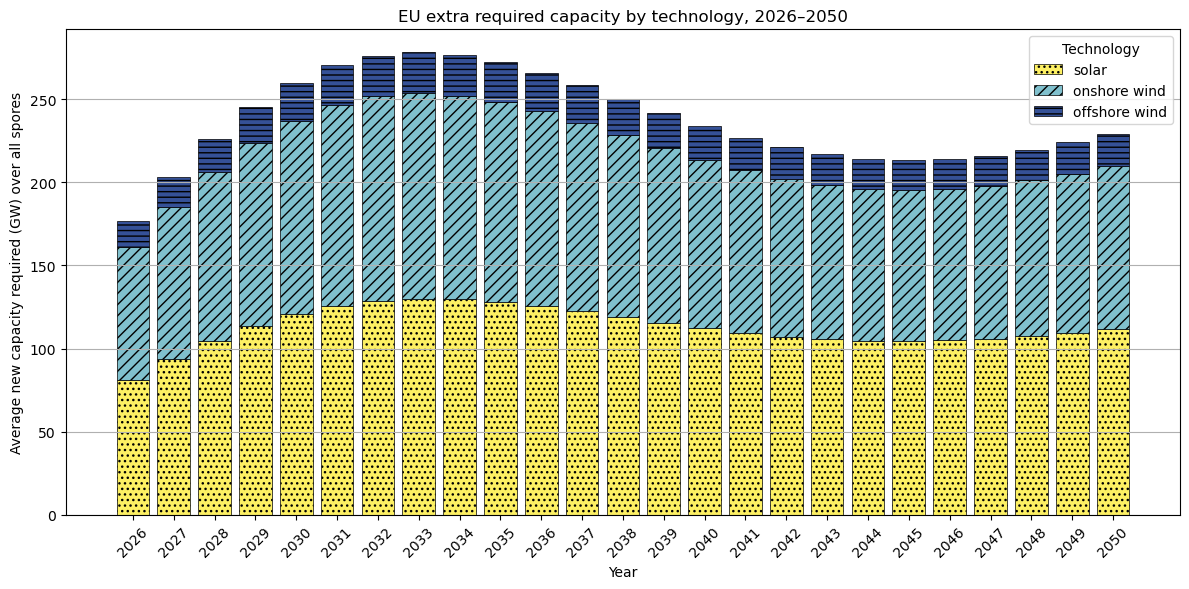

In [75]:
colors = {
    "solar": "#FDF063",
    "onshore wind": "#80C0CD",
    "offshore wind": "#355197",
    "batteries": "#D2ABC3"
}

hatches = {
    "solar": "...",
    "onshore wind": "///",
    "offshore wind": "---",
    "batteries": "++"
}

plt.figure(figsize=(12, 6))

bottom = np.zeros(len(buildout_pivot))

for tech in techs_to_plot:
    plt.bar(
        buildout_pivot.index,
        buildout_pivot[tech],
        bottom=bottom,
        label=tech,
        color=colors.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.5,
        hatch=hatches.get(tech, ""),
    )
    
    bottom += buildout_pivot[tech].values

plt.xlabel("Year")
plt.ylabel("Average new capacity required (GW) over all spores")
plt.title("EU extra required capacity by technology, 2026–2050")
plt.xticks(buildout_pivot.index, rotation=45)
plt.legend(title="Technology")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [76]:
# Technologies and period
techs_to_plot = ["batteries"]

df_buildout = annual_buildout_df[
    (annual_buildout_df["tech"].isin(techs_to_plot)) &
    (annual_buildout_df["year"] >= 2026) &
    (annual_buildout_df["year"] <= 2050)
].copy()


# Average over all spores

EU_buildout_by_spore_year = (
    df_buildout
    .groupby(["spore", "year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
)

EU_buildout_by_year_mean = (
    EU_buildout_by_spore_year
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_GW"]
    .mean()
)


buildout_pivot = EU_buildout_by_year_mean.pivot(
    index="year",
    columns="tech",
    values="new_capacity_required_GW"
).fillna(0)

buildout_pivot = buildout_pivot.reindex(columns=techs_to_plot).fillna(0)

print(buildout_pivot.head())

tech  batteries
year           
2026   7.317208
2027   8.542021
2028   9.660259
2029  10.637110
2030  11.454616


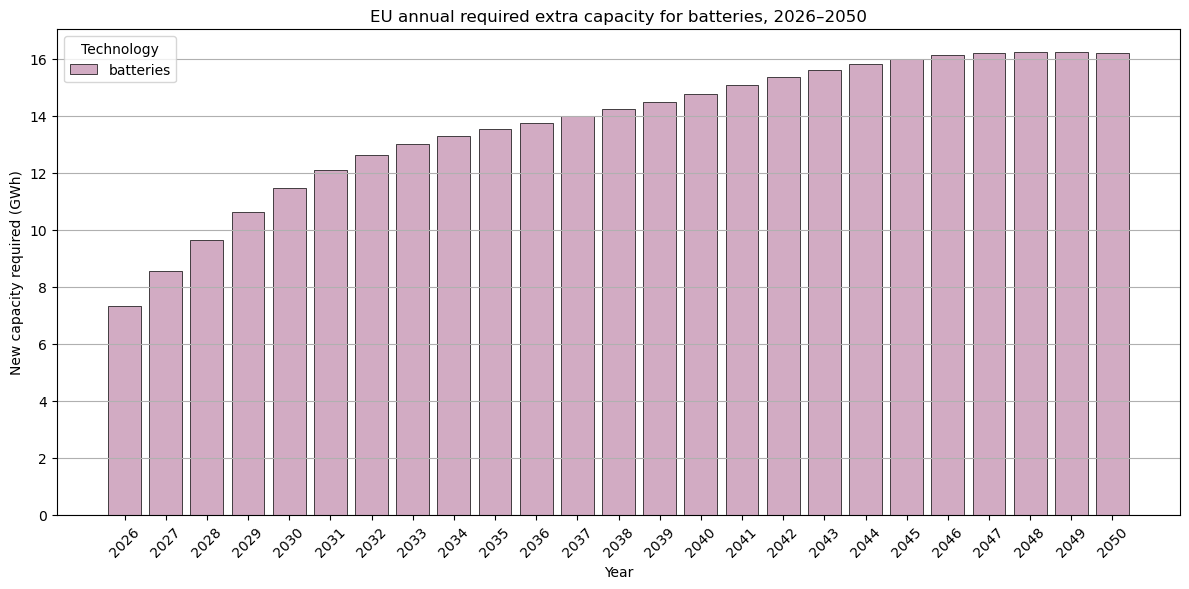

In [77]:
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(buildout_pivot))

for tech in techs_to_plot:
    plt.bar(
        buildout_pivot.index,
        buildout_pivot[tech],
        bottom=bottom,
        label=tech,
        color=colors.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.5,
    )
    bottom += buildout_pivot[tech].values

plt.xlabel("Year")
plt.ylabel("New capacity required (GWh)")
plt.title("EU annual required extra capacity for batteries, 2026–2050")
plt.xticks(buildout_pivot.index, rotation=45)
plt.legend(title="Technology")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

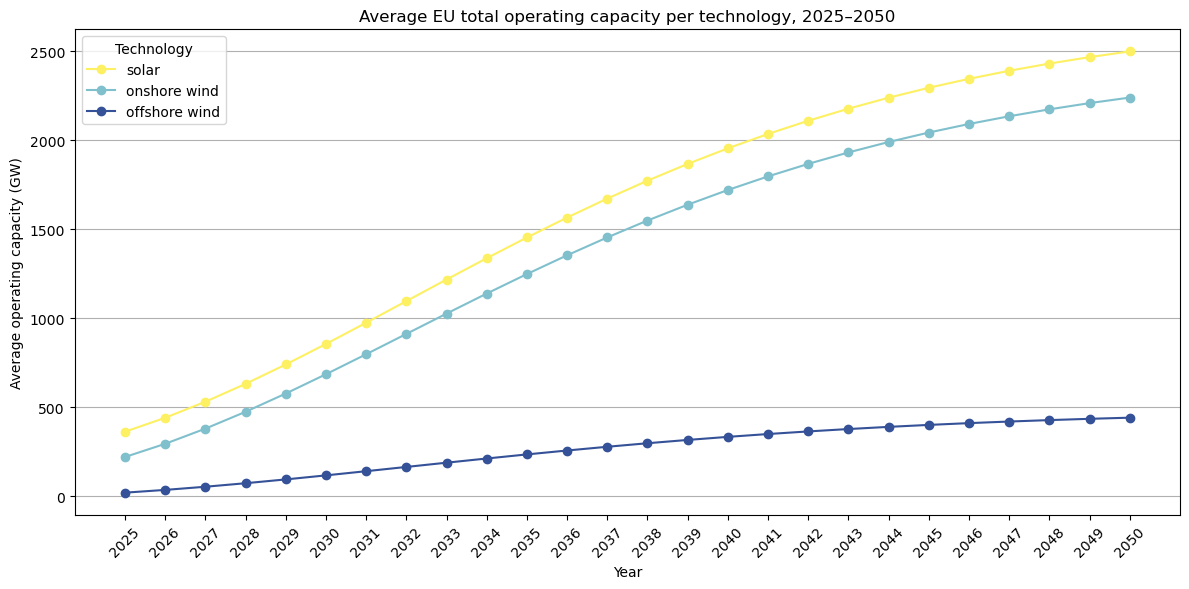

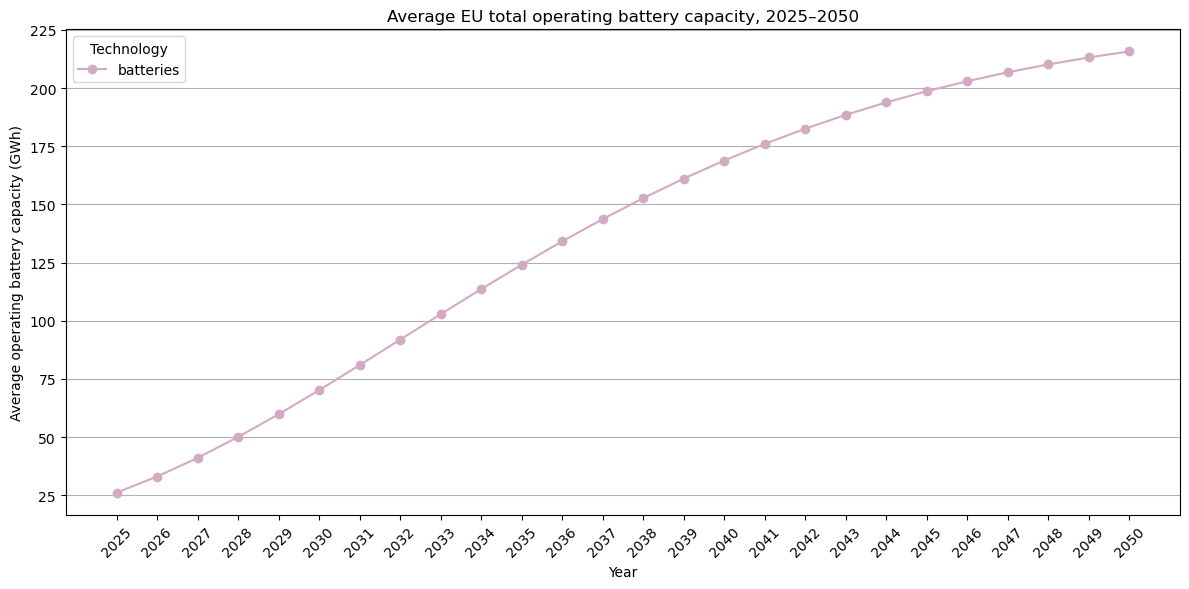

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

techs_to_plot = ["solar", "onshore wind", "offshore wind"]
battery_tech = "batteries"

start_year = 2025
end_year = 2050


# Average over all spores

eu_capacity_by_spore_year = (
    annual_buildout_df
    .groupby(["spore", "year", "tech"], as_index=False)["operating_capacity_after_build_GW"]
    .sum()
)

eu_capacity_mean = (
    eu_capacity_by_spore_year
    .groupby(["year", "tech"], as_index=False)["operating_capacity_after_build_GW"]
    .mean()
)

eu_capacity_mean = eu_capacity_mean.rename(
    columns={
        "operating_capacity_after_build_GW": "operating_capacity_GW"
    }
)


# 2025

start_rows = []

for tech in techs_to_plot + [battery_tech]:

    capacity_2025_GW = sum(
        EU_capacities_2025[country][tech]
        for country in EU_countries
        if country in EU_capacities_2025
    )

    start_rows.append({
        "year": 2025,
        "tech": tech,
        "operating_capacity_GW": capacity_2025_GW
    })

start_df = pd.DataFrame(start_rows)


plot_data = pd.concat(
    [
        start_df,
        eu_capacity_mean[["year", "tech", "operating_capacity_GW"]]
    ],
    ignore_index=True
)

plot_data = plot_data.sort_values(["tech", "year"])


# Techs

plt.figure(figsize=(12, 6))

for tech in techs_to_plot:

    df_tech = plot_data[plot_data["tech"] == tech]

    plt.plot(
        df_tech["year"],
        df_tech["operating_capacity_GW"],
        marker="o",
        label=tech,
        color=colors.get(tech, "grey"),
    )

plt.xlabel("Year")
plt.ylabel("Average operating capacity (GW)")
plt.title("Average EU total operating capacity per technology, 2025–2050")
plt.xticks(range(start_year, end_year + 1), rotation=45)
plt.grid(True, axis="y")
plt.legend(title="Technology")

plt.tight_layout()
plt.show()


# Storage tech

df_battery = plot_data[plot_data["tech"] == battery_tech]

plt.figure(figsize=(12, 6))

plt.plot(
    df_battery["year"],
    df_battery["operating_capacity_GW"],
    marker="o",
    label="batteries",
    color=colors.get("batteries", "grey"),
)

plt.xlabel("Year")
plt.ylabel("Average operating battery capacity (GWh)")
plt.title("Average EU total operating battery capacity, 2025–2050")
plt.xticks(range(start_year, end_year + 1), rotation=45)
plt.grid(True, axis="y")
plt.legend(title="Technology")

plt.tight_layout()
plt.show()

Material Demand

In [79]:
buildout = annual_buildout_df[
    [
        "spore",
        "country",
        "year",
        "tech",
        "new_capacity_required_GW"
    ]
].copy()

# Alleen positieve nieuwbouw meenemen
buildout["new_capacity_required_GW"] = (
    buildout["new_capacity_required_GW"].clip(lower=0)
)

material_demand = buildout.merge(
    material_intensities[
        [
            "tech",
            "Material",
            "Material Intensity (ton/TW)"
        ]
    ],
    on="tech",
    how="left"
)



material_demand["material_required_tonnes"] = (
    material_demand["new_capacity_required_GW"]
    * (material_demand["Material Intensity (ton/TW)"] / 1000)
)



materials_country_year = (
    material_demand
    .groupby(
        ["spore", "country", "year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)



materials_EU_year = (
    material_demand
    .groupby(
        ["spore", "year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)


print("\nEU-totaal per jaar:")
print(materials_EU_year)


EU-totaal per jaar:
       spore  year            Material  material_required_tonnes
0          0  2026            aluminum              1.229413e+06
1          0  2026               boron              2.071257e+02
2          0  2026            chromium              3.884346e+04
3          0  2026              cobalt              2.229589e+02
4          0  2026              copper              4.313768e+05
...      ...   ...                 ...                       ...
49270     72  2050  sum of rare earths              7.007322e+03
49271     72  2050                 tin              8.617836e+03
49272     72  2050            titanium              1.074129e+04
49273     72  2050            tungsten              0.000000e+00
49274     72  2050                zinc              1.799537e+05

[49275 rows x 4 columns]
